In [1]:
import pandas as pd
df = pd.read_csv("crime data1.csv")
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025 0:00,2/21/2025 0:00,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895
1005194,250304203,2/20/2025 0:00,2/13/2025 0:00,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",...,IC,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923
1005195,250504051,1/14/2025 0:00,1/14/2025 0:00,1250,5,Harbor,509,1,210,ROBBERY,...,IC,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074
1005196,251604136,2/27/2025 0:00,2/27/2025 0:00,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,NaN,NaN,NaN,11900 SHELDON ST,NaN,34.2404,-118.3922


In [77]:
df.shape

(729626, 30)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# pip install streamlit


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# !streamlit run crime prediction.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Streamlit requires raw Python (.py) files, but the provided file has no extension.
For more information, please see https://docs.streamlit.io


In [3]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  object 
 2   DATE OCC        1005198 non-null  object 
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  object 
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  object 
 10  Mocodes         853438 non-null   object 
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   object 
 13  Vict Descent    860404 non-null   object 
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  object 
 16  Weapon Used Cd  327280 non-null   fl

In [5]:
df.isnull().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151760
Vict Age                0
Vict Sex           144782
Vict Descent       144794
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677918
Weapon Desc        677918
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           936039
Crm Cd 3          1002884
Crm Cd 4          1005134
LOCATION                0
Cross Street       850955
LAT                     0
LON                     0
dtype: int64

In [8]:
df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005182e+06,327280.000000,1.005187e+06,69159.000000,2314.000000,64.00000,1.005198e+06,1.005198e+06
mean,2.202277e+08,1.339911e+03,1.069098e+01,1.115556e+03,1.400283e+00,5.001458e+02,2.891253e+01,3.056189e+02,363.953651,4.999063e+02,958.105221,984.015990,991.21875,3.399820e+01,-1.180909e+02
std,1.320282e+07,6.510531e+02,6.110385e+00,6.111733e+02,4.899559e-01,2.052635e+02,2.199382e+01,2.193160e+02,123.736081,2.050640e+02,110.354136,52.350982,27.06985,1.610549e+00,5.581812e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106169e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209160e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311105e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


In [9]:
# pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
########## CLEANINNG DATA ############

In [6]:
object_cols = df.select_dtypes(include='object').columns
print(object_cols)

Index(['Date Rptd', 'DATE OCC', 'AREA NAME', 'Crm Cd Desc', 'Mocodes',
       'Vict Sex', 'Vict Descent', 'Premis Desc', 'Weapon Desc', 'Status',
       'Status Desc', 'LOCATION', 'Cross Street'],
      dtype='object')


In [7]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [8]:
df = df.drop(['Crm Cd 1','Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4'], axis=1)

In [9]:
df.columns = df.columns.str.lower().str.strip()

In [10]:
df['date occ'] = pd.to_datetime(df['date occ'])
df['date rptd'] = pd.to_datetime(df['date rptd'])

In [11]:
df.fillna({
    'vict sex': 'Unknown',
    'vict descent': 'Unknown',
    'weapon desc': 'Not Reported',
    'cross street': 'Unknown'
}, inplace=True)

In [12]:
df['weapon used cd'] = df['weapon used cd'].fillna(0)
df['premis cd'] = df['premis cd'].fillna(df['premis cd'].median())

In [13]:
df['vict age'].describe()

count    1.005198e+06
mean     2.891253e+01
std      2.199382e+01
min     -4.000000e+00
25%      0.000000e+00
50%      3.000000e+01
75%      4.400000e+01
max      1.200000e+02
Name: vict age, dtype: float64

In [14]:
df = df[(df['vict age'] > 0) & (df['vict age'] < 100)]

In [15]:
df['vict age'].describe()

count    735684.000000
mean         39.504573
std          15.571852
min           2.000000
25%          28.000000
50%          37.000000
75%          50.000000
max          99.000000
Name: vict age, dtype: float64

In [16]:
df.isnull().sum()

dr_no                0
date rptd            0
date occ             0
time occ             0
area                 0
area name            0
rpt dist no          0
part 1-2             0
crm cd               0
crm cd desc          0
mocodes           5683
vict age             0
vict sex             0
vict descent         0
premis cd            0
premis desc        229
weapon used cd       0
weapon desc          0
status               0
status desc          0
location             0
cross street         0
lat                  0
lon                  0
dtype: int64

In [17]:
df = df.drop('mocodes', axis=1)

In [18]:
df['premis desc'] = df['premis desc'].fillna('Unknown')

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.dtypes

dr_no                      int64
date rptd         datetime64[ns]
date occ          datetime64[ns]
time occ                   int64
area                       int64
area name                 object
rpt dist no                int64
part 1-2                   int64
crm cd                     int64
crm cd desc               object
vict age                   int64
vict sex                  object
vict descent              object
premis cd                float64
premis desc               object
weapon used cd           float64
weapon desc               object
status                    object
status desc               object
location                  object
cross street              object
lat                      float64
lon                      float64
dtype: object

In [21]:
df['vict sex'].unique()

array(['M', 'X', 'F', 'H', 'Unknown'], dtype=object)

In [22]:
df['vict sex'] = df['vict sex'].replace({
    'X': 'Unknown',
    'H': 'Unknown'
})

df['vict sex'] = df['vict sex'].fillna('Unknown')

In [23]:
df['vict sex'].unique()

array(['M', 'Unknown', 'F'], dtype=object)

In [24]:
df[['lat','lon']].describe()

,lat,lon
count,735684.000000,735684.00000
mean,33.997387,-118.08504
std,1.636008,5.67054
min,0.000000,-118.66760
25%,34.015500,-118.43350
50%,34.059200,-118.32650
75%,34.166400,-118.27600
max,34.334300,0.00000


In [25]:
df = df[(df['lat'] != 0) & (df['lon'] != 0)]

In [26]:
df[['lat','lon']].describe()

,lat,lon
count,733992.000000,733992.00000
mean,34.075758,-118.35725
std,0.110193,0.10532
min,33.705900,-118.66760
25%,34.016200,-118.43380
50%,34.059400,-118.32660
75%,34.166500,-118.27610
max,34.334300,-118.15540


In [27]:
df.isnull().sum()

dr_no             0
date rptd         0
date occ          0
time occ          0
area              0
area name         0
rpt dist no       0
part 1-2          0
crm cd            0
crm cd desc       0
vict age          0
vict sex          0
vict descent      0
premis cd         0
premis desc       0
weapon used cd    0
weapon desc       0
status            0
status desc       0
location          0
cross street      0
lat               0
lon               0
dtype: int64

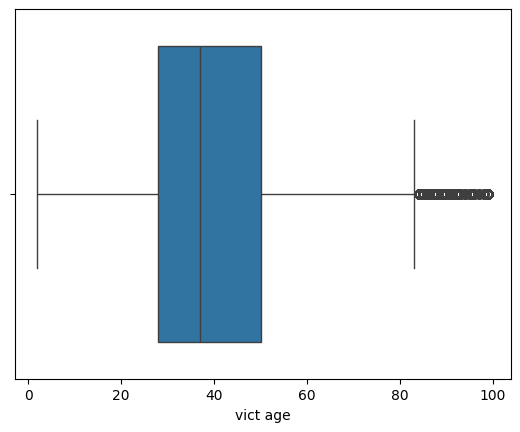

In [28]:
sns.boxplot(x=df['vict age'])
plt.show()

In [29]:
Q1 = df['vict age'].quantile(0.25)
Q3 = df['vict age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['vict age'] >= lower) & (df['vict age'] <= upper)]

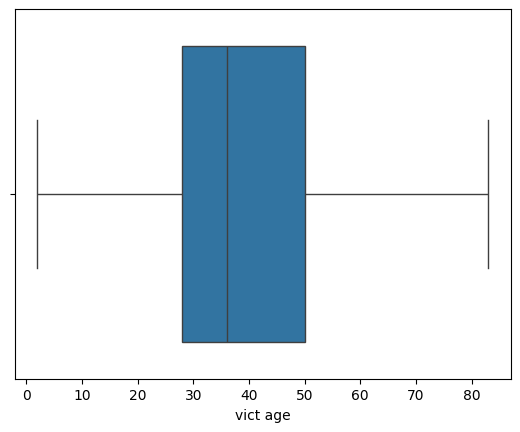

In [35]:
sns.boxplot(x=df['vict age'])
plt.show()

In [30]:
df['vict age'].describe()

count    729626.000000
mean         39.205788
std          15.134744
min           2.000000
25%          28.000000
50%          36.000000
75%          50.000000
max          83.000000
Name: vict age, dtype: float64

In [31]:
original_rows = df.shape[0]
print(original_rows)

729626


In [32]:
############ FEATURE ENGINEERING ##############

In [33]:
df['year'] = df['date occ'].dt.year
df['month'] = df['date occ'].dt.month
df['day'] = df['date occ'].dt.day
df['weekday'] = df['date occ'].dt.weekday

In [34]:
df['hour'] = df['time occ'] // 100

In [35]:
df['age_group'] = pd.cut(
    df['vict age'],
    bins=[0, 18, 30, 50, 100],
    labels=['Teen', 'Young', 'Adult', 'Senior']
)

In [36]:
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [37]:
df['time_category'] = pd.cut(
    df['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

In [38]:
df['age_group'].value_counts()

age_group
Adult     314732
Young     211585
Senior    171651
Teen       31658
Name: count, dtype: int64

In [39]:
area_freq = df['area name'].value_counts().to_dict()
df['area_crime_count'] = df['area name'].map(area_freq)

In [40]:
df.drop(['day'], axis=1, inplace=True)

In [41]:
df.drop(['date occ', 'date rptd', 'time occ', 'location', 'cross street'], axis=1, inplace=True)

In [42]:
df.head()
df.columns

Index(['dr_no', 'area', 'area name', 'rpt dist no', 'part 1-2', 'crm cd',
       'crm cd desc', 'vict age', 'vict sex', 'vict descent', 'premis cd',
       'premis desc', 'weapon used cd', 'weapon desc', 'status', 'status desc',
       'lat', 'lon', 'year', 'month', 'weekday', 'hour', 'age_group',
       'is_weekend', 'time_category', 'area_crime_count'],
      dtype='object')

In [43]:
############ EXPLORATORY DATA ANALYSIS(EDA)  ##############

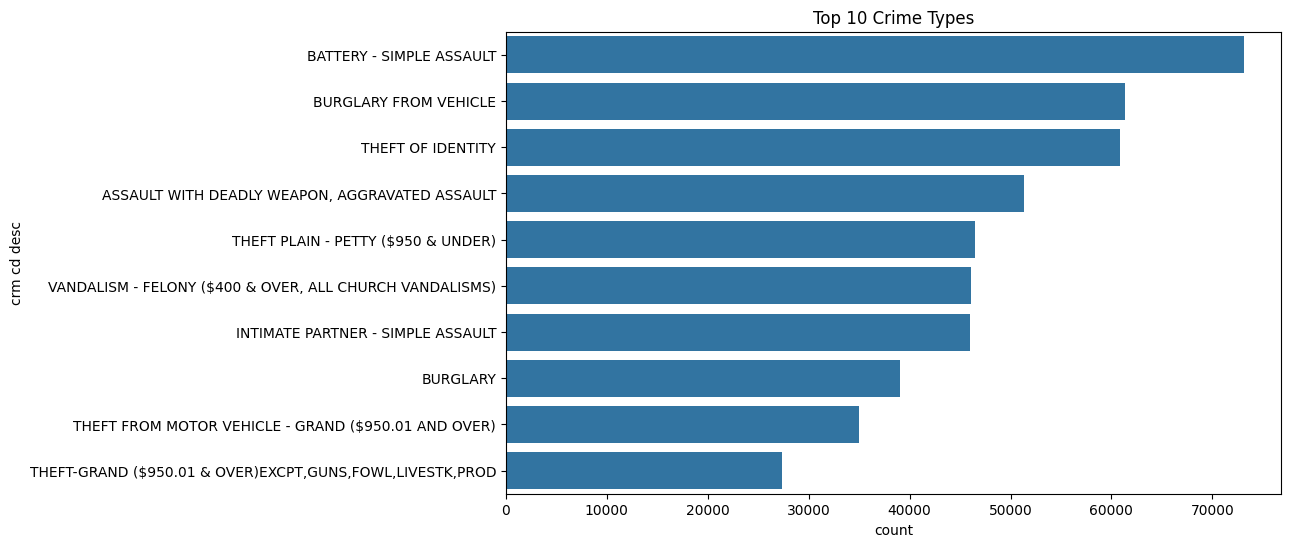

In [44]:
plt.figure(figsize=(10,6))
sns.countplot(
    y='crm cd desc',
    data=df,
    order=df['crm cd desc'].value_counts().index[:10]
)
plt.title("Top 10 Crime Types")
plt.show()

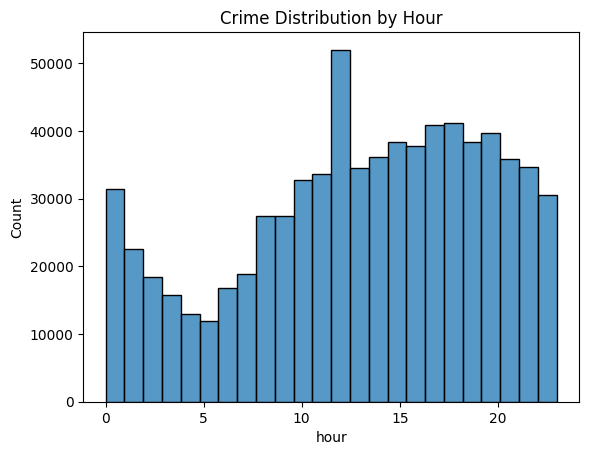

In [45]:
sns.histplot(df['hour'], bins=24)
plt.title("Crime Distribution by Hour")
plt.show()

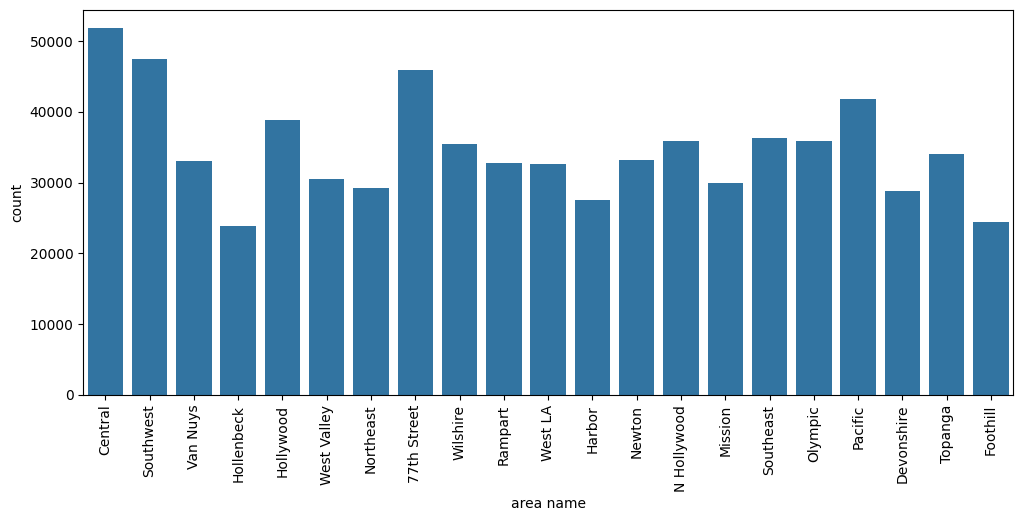

In [46]:
plt.figure(figsize=(12,5))
sns.countplot(x='area name', data=df)
plt.xticks(rotation=90)
plt.show()

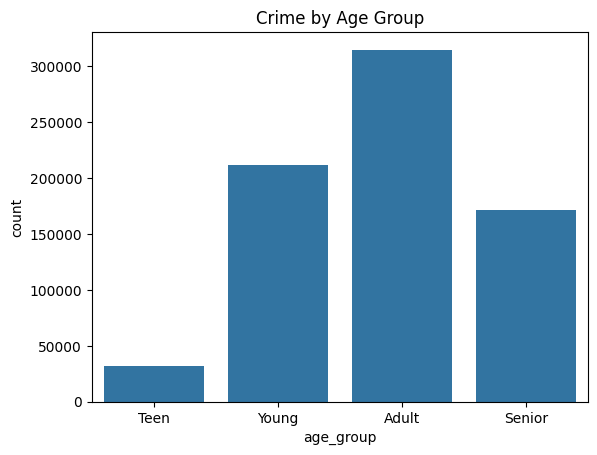

In [47]:
sns.countplot(x='age_group', data=df)
plt.title("Crime by Age Group")
plt.show()

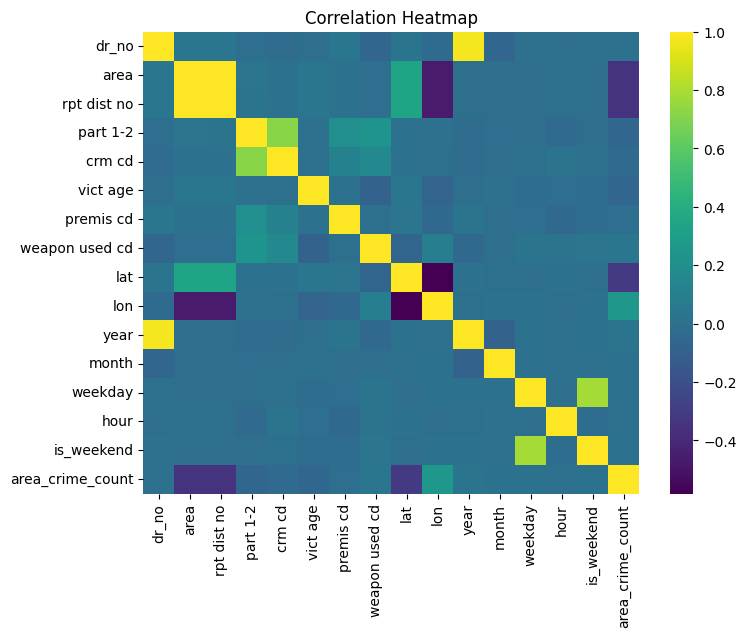

In [49]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='viridis',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [50]:
################ ENCODING #############

In [51]:
df.select_dtypes(include='object').columns

Index(['area name', 'crm cd desc', 'vict sex', 'vict descent', 'premis desc',
       'weapon desc', 'status', 'status desc'],
      dtype='object')

In [52]:
le = LabelEncoder()

for col in ['vict sex', 'vict descent', 'status desc']:
    df[col] = le.fit_transform(df[col])

In [53]:
df['age_group'] = pd.cut(
    df['vict age'],
    bins=[0, 18, 30, 50, 100],
    labels=['Teen', 'Young', 'Adult', 'Senior']
)

In [54]:
df['time_category'] = pd.cut(
    df['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

In [55]:
df = pd.get_dummies(df, columns=['age_group', 'time_category'], drop_first=True)

In [56]:
freq = df['area name'].value_counts().to_dict()
df['area name'] = df['area name'].map(freq)

In [57]:
df.to_csv("cleaned_crime data1.csv", index=False)

In [58]:
############### MODEL BUILDING ##############

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729626 entries, 1 to 1005197
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   dr_no                    729626 non-null  int64  
 1   area                     729626 non-null  int64  
 2   area name                729626 non-null  int64  
 3   rpt dist no              729626 non-null  int64  
 4   part 1-2                 729626 non-null  int64  
 5   crm cd                   729626 non-null  int64  
 6   crm cd desc              729626 non-null  object 
 7   vict age                 729626 non-null  int64  
 8   vict sex                 729626 non-null  int64  
 9   vict descent             729626 non-null  int64  
 10  premis cd                729626 non-null  float64
 11  premis desc              729626 non-null  object 
 12  weapon used cd           729626 non-null  float64
 13  weapon desc              729626 non-null  object 
 14  status  

In [60]:
df.columns

Index(['dr_no', 'area', 'area name', 'rpt dist no', 'part 1-2', 'crm cd',
       'crm cd desc', 'vict age', 'vict sex', 'vict descent', 'premis cd',
       'premis desc', 'weapon used cd', 'weapon desc', 'status', 'status desc',
       'lat', 'lon', 'year', 'month', 'weekday', 'hour', 'is_weekend',
       'area_crime_count', 'age_group_Young', 'age_group_Adult',
       'age_group_Senior', 'time_category_Morning', 'time_category_Afternoon',
       'time_category_Evening'],
      dtype='object')

In [61]:
[col for col in df.columns if 'crm' in col]

['crm cd', 'crm cd desc']

In [62]:
y = df['crm cd desc']
X = df.drop('crm cd desc', axis=1)

In [63]:
le_target = LabelEncoder()
y = le_target.fit_transform(y)

In [64]:
cat_cols = X.select_dtypes(include='object').columns

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [66]:
model = RandomForestClassifier(n_estimators=80,max_depth=15,min_samples_split=4,random_state=42,n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [67]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9287447062209613


In [68]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.27      0.42       298
           1       1.00      0.47      0.64        47
           2       0.98      1.00      0.99     10115
           3       1.00      0.87      0.93       788
           4       0.99      1.00      1.00     14563
           5       1.00      0.09      0.17        33
           6       0.97      0.72      0.83       151
           7       0.78      0.89      0.83       843
          11       0.89      0.79      0.84      1521
          12       0.00      0.00      0.00         1
          13       1.00      0.30      0.46        20
          14       0.96      1.00      0.98      2843
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00        53
          17       0.72      0.68      0.70      1141
          18       1.00      0.00      0.01       368
          19       0.99      1.00      0.99      7921
          20       0.99    

C:\Users\TANUJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TANUJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TANUJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

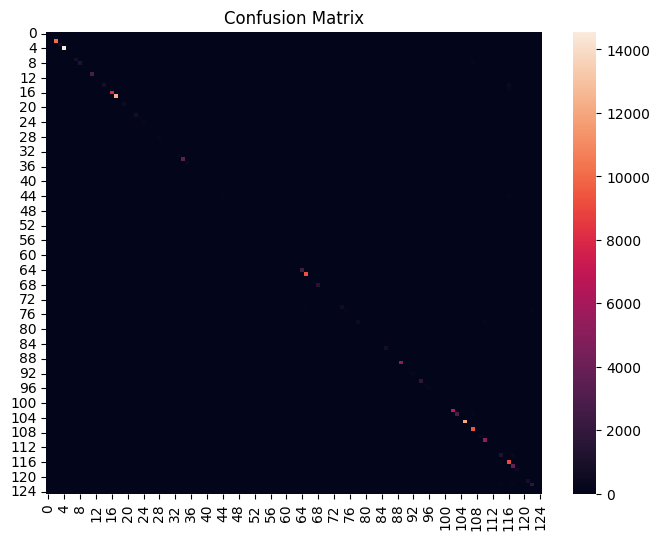

In [70]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()

In [71]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance.head(10))

crm cd            0.558786
part 1-2          0.098484
weapon used cd    0.090782
weapon desc       0.071679
premis cd         0.049981
premis desc       0.032406
status desc       0.012747
vict age          0.012001
status            0.009303
vict sex          0.007526
dtype: float64


In [72]:
import pickle
pickle.dump(model, open('crime_model.pkl', 'wb'))

In [77]:
import pickle

pickle.dump(le_target, open('target_encoder.pkl', 'wb'))

In [78]:
pickle.dump(le_dict, open('feature_encoders.pkl', 'wb'))

In [79]:
model = pickle.load(open('crime_model.pkl', 'rb'))
le_target = pickle.load(open('target_encoder.pkl', 'rb'))
le_dict = pickle.load(open('feature_encoders.pkl', 'rb'))

In [73]:
st.title("Crime Type Prediction System")
st.write("Enter crime details to predict crime category")

2026-06-26 15:22:05.397 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.089 
  command:

    streamlit run C:\Users\TANUJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-26 15:22:09.091 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.095 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.101 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.108 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [74]:
area = st.number_input("Area", min_value=1, value=1)

vict_age = st.number_input(
    "Victim Age",
    min_value=1,
    max_value=100,
    value=25
)

crm_cd = st.number_input(
    "Crime Code",
    min_value=100,
    value=624
)

vict_sex = st.selectbox(
    "Victim Sex",
    ['M', 'F']
)

weapon_desc = st.selectbox(
    "Weapon Description",
    [
        'UNKNOWN WEAPON/OTHER WEAPON',
        'STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)',
        'VERBAL THREAT'
    ]
)

2026-06-26 15:22:09.276 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.280 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.282 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.287 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.290 Session state does not function when running a script without `streamlit run`
2026-06-26 15:22:09.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22:09.301 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 15:22

In [75]:
vict_sex_encoded = le_dict['vict sex'].transform([vict_sex])[0]
weapon_encoded = le_dict['weapon desc'].transform([weapon_desc])[0]

KeyError: 'vict sex'

In [ ]:
input_data = pd.DataFrame({
    'area': [area],
    'vict age': [vict_age],
    'crm cd': [crm_cd],
    'vict sex': [vict_sex_encoded],
    'weapon desc': [weapon_encoded]
})

In [ ]:
if st.button("Predict Crime Type"):

    prediction = model.predict(input_data)

    predicted_label = le_target.inverse_transform(prediction)

    st.success(f"Predicted Crime Type: {predicted_label[0]}")